# X-Ray Detection v6 — Top-Scorer Strategy

Henri BOISSON - Computer Vision 
Kaggle competition
DSBA

The main idea of the approach:
1. **Multi-method region proposals** (thresholding + Canny + morpho + MSER)
2. **Rich features** (intensity, gradients, shape, Hu moments, LBP texture)
3. **XGBoost** classifier with class imbalance handling
4. **Hard negative mining** (2 rounds)
5. **Per-class post-processing** (thresholds, NMS, size filters)

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — SETUP & INSTALL
# ═══════════════════════════════════════════════════════════════
!pip install xgboost opencv-contrib-python==4.8.1.78 --quiet

from google.colab import drive
drive.mount('/content/drive')

import os, shutil
from pathlib import Path
from google.colab import files as colab_files

#WE LOAD THE KAGGLE DATASET

if Path('/content/xray_data').exists() and any(Path('/content/xray_data').rglob('*.jpg')):
    print('Data already exists, skipping download.')
else:
    print('Select your kaggle.json file:')
    uploaded = colab_files.upload()
    os.makedirs('/root/.kaggle', exist_ok=True)
    shutil.copy('kaggle.json', '/root/.kaggle/kaggle.json')
    !chmod 600 /root/.kaggle/kaggle.json
    print('Downloading...')
    !kaggle competitions download -c cv-object-detection-in-baggage-using-classic-computer-vision -p /content/
    print('Unzipping...')
    !unzip -q /content/cv-object-detection-in-baggage-using-classic-computer-vision.zip -d /content/xray_data/

print('Setup done!')

KeyboardInterrupt: 

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — SETUP & INSTALL (fixes numpy compatibility)
# ═══════════════════════════════════════════════════════════════
!pip install "numpy<2" --quiet
!pip install opencv-contrib-python==4.8.1.78 --quiet
!pip install xgboost --quiet

# On colab after this: we restart the runtime to make sure the new numpy version is being used.
#Then we can run the rest of the code starting from cell2.

Now restart runtime: Runtime → Restart runtime
Then skip this cell and run from Cell 2 onward.


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — IMPORTS & CONFIG
# ═══════════════════════════════════════════════════════════════
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from skimage.feature import local_binary_pattern
import xgboost as xgb
import pickle, random, warnings, time
from tqdm import tqdm
from collections import defaultdict
import pandas as pd
import ast
warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

# WE CONFIG THE PATH
BASE = Path('/content/xray_data')
candidates = list(BASE.rglob('images/train'))
DATA = candidates[0].parent.parent if candidates else BASE

TRAIN_IMG = DATA / 'images' / 'train'
TRAIN_LBL = DATA / 'labels' / 'train'
VAL_IMG   = DATA / 'images' / 'val'
VAL_LBL   = DATA / 'labels' / 'val'
TEST_IMG  = DATA / 'test'
if not TEST_IMG.exists() or not any(TEST_IMG.glob('*.jpg')):
    for c in BASE.rglob('test'):
        if c.is_dir() and (list(c.glob('*.jpg')) or list(c.glob('*.png'))):
            TEST_IMG = c; break

print(f'Train: {len(list(TRAIN_IMG.glob("*")))} | Val: {len(list(VAL_IMG.glob("*")))} | Test: {len(list(TEST_IMG.glob("*")))}')

CLASS_NAMES = {0:'Hammer', 1:'Knife', 2:'Gun', 3:'Wrench', 4:'HandCuffs', 5:'Bullet'}
NUM_CLASSES = 6
BG_LABEL = 6  
CLASS_COLORS = ['red','blue','green','orange','purple','cyan']
print('Config ready!')

Train: 4200 | Val: 900 | Test: 900
Config ready!


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — HELPER FUNCTIONS
# ═══════════════════════════════════════════════════════════════

def parse_yolo_labels(label_path):
    boxes = []
    if not label_path.exists(): return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                boxes.append((int(parts[0]), *map(float, parts[1:])))
    return boxes

def yolo_to_pixel(cx, cy, bw, bh, img_w, img_h):
    x1 = int((cx - bw/2) * img_w)
    y1 = int((cy - bh/2) * img_h)
    x2 = int((cx + bw/2) * img_w)
    y2 = int((cy + bh/2) * img_h)
    return max(0,x1), max(0,y1), min(img_w,x2), min(img_h,y2)

def pixel_to_yolo(x1, y1, x2, y2, img_w, img_h):
    return ((x1+x2)/2)/img_w, ((y1+y2)/2)/img_h, (x2-x1)/img_w, (y2-y1)/img_h

def nms(boxes, scores, iou_threshold=0.3):
    if len(boxes) == 0: return []
    x1,y1,x2,y2 = boxes[:,0].astype(float),boxes[:,1].astype(float),boxes[:,2].astype(float),boxes[:,3].astype(float)
    areas = (x2-x1)*(y2-y1)
    order = scores.argsort()[::-1]
    keep = []
    while order.size > 0:
        i = order[0]; keep.append(i)
        xx1=np.maximum(x1[i],x1[order[1:]]); yy1=np.maximum(y1[i],y1[order[1:]])
        xx2=np.minimum(x2[i],x2[order[1:]]); yy2=np.minimum(y2[i],y2[order[1:]])
        inter = np.maximum(0,xx2-xx1)*np.maximum(0,yy2-yy1)
        iou = inter/(areas[i]+areas[order[1:]]-inter+1e-6)
        order = order[np.where(iou <= iou_threshold)[0]+1]
    return keep

def compute_iou(box1, box2):
    """IoU between two YOLO boxes (cx,cy,w,h)."""
    b1x1,b1y1=box1[0]-box1[2]/2, box1[1]-box1[3]/2
    b1x2,b1y2=box1[0]+box1[2]/2, box1[1]+box1[3]/2
    b2x1,b2y1=box2[0]-box2[2]/2, box2[1]-box2[3]/2
    b2x2,b2y2=box2[0]+box2[2]/2, box2[1]+box2[3]/2
    ix1,iy1=max(b1x1,b2x1),max(b1y1,b2y1)
    ix2,iy2=min(b1x2,b2x2),min(b1y2,b2y2)
    inter=max(0,ix2-ix1)*max(0,iy2-iy1)
    union=box1[2]*box1[3]+box2[2]*box2[3]-inter
    return inter/(union+1e-8)

def evaluate_frame(gt_boxes, pred_boxes):
    if len(gt_boxes)==0 and len(pred_boxes)==0: return 1.0
    if len(gt_boxes)==0 or len(pred_boxes)==0: return 0.0
    used=set(); iou_sum=0.0
    for gt in gt_boxes:
        best_iou,best_j=0.0,-1
        for j,pred in enumerate(pred_boxes):
            if j in used or pred[0]!=gt[0]: continue
            iou=compute_iou(gt[1:],pred[1:])
            if iou>best_iou: best_iou,best_j=iou,j
        if best_j>=0: used.add(best_j)
        iou_sum+=best_iou
    return iou_sum/max(len(gt_boxes),len(pred_boxes))

print('Helpers loaded!')

Helpers loaded!


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — MULTI-METHOD REGION PROPOSALS
# ═══════════════════════════════════════════════════════════════
# We combine multiple classical CV techniques to generate a rich set of region proposals, which will then be classified by our XGBoost model. 


def get_region_proposals(img_gray):
    h, w = img_gray.shape[:2]
    min_area = 200
    max_area = int(h * w * 0.5)
    proposals = set()

    def valid_and_add(x, y, bw, bh):
        area = bw * bh
        if area < min_area or area > max_area: return
        if max(bw,bh)/(min(bw,bh)+1e-6) > 8: return
        proposals.add((x, y, x+bw, y+bh))

    def contours_to_proposals(binary):
        contours,_ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for cnt in contours:
            x,y,bw,bh = cv2.boundingRect(cnt)
            valid_and_add(x,y,bw,bh)

    # METHOD 1: Multi-level thresholding 
    blurred = cv2.GaussianBlur(img_gray, (5,5), 0)
    _, otsu = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours_to_proposals(otsu)
    contours_to_proposals(255 - otsu)  

    # We try thresholds at multiple levels
    for thr_val in [30, 60, 90, 120, 150, 180, 210]:
        _, binary = cv2.threshold(blurred, thr_val, 255, cv2.THRESH_BINARY)
        contours_to_proposals(binary)
        contours_to_proposals(255 - binary)

    # We apply an adaptive threshold
    adapt = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                   cv2.THRESH_BINARY, 31, 5)
    contours_to_proposals(adapt)
    contours_to_proposals(255 - adapt)

    # METHOD 2: Canny edges
    canny_configs = [
        (5,25,90,3), (7,50,150,2), (5,15,70,4),
        (9,40,120,3), (3,60,180,1), (5,80,200,2),
    ]
    for blur_k,c_lo,c_hi,d_iter in canny_configs:
        bl = cv2.GaussianBlur(img_gray,(blur_k,blur_k),0)
        edges = cv2.Canny(bl, c_lo, c_hi)
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT,(5,5))
        dilated = cv2.dilate(edges, kernel, iterations=d_iter)
        contours_to_proposals(dilated)

    # METHOD 3: Morphological operations. 
    # We check for dark and bright objects. 
    for ksize in [5, 9, 15]:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize,ksize))
        tophat = cv2.morphologyEx(img_gray, cv2.MORPH_TOPHAT, kernel)
        _, th = cv2.threshold(tophat, 30, 255, cv2.THRESH_BINARY)
        contours_to_proposals(th)
        blackhat = cv2.morphologyEx(img_gray, cv2.MORPH_BLACKHAT, kernel)
        _, bh_bin = cv2.threshold(blackhat, 30, 255, cv2.THRESH_BINARY)
        contours_to_proposals(bh_bin)

    # METHOD 4: MSER 
    try:
        mser = cv2.MSER_create()
        mser.setMinArea(min_area)
        mser.setMaxArea(max_area)
        regions, _ = mser.detectRegions(img_gray)
        for region in regions:
            x,y,bw,bh = cv2.boundingRect(region)
            valid_and_add(x,y,bw,bh)
    except:
        pass

    # We add variants to increase recall, by padding the boxes.
    expanded = list(proposals)
    for (x1,y1,x2,y2) in list(proposals):
        bw,bh = x2-x1, y2-y1
        for pad in [0.1, 0.2]:
            pw,ph = int(bw*pad), int(bh*pad)
            nx1,ny1 = max(0,x1-pw), max(0,y1-ph)
            nx2,ny2 = min(w,x2+pw), min(h,y2+ph)
            if (nx2-nx1)*(ny2-ny1) < max_area:
                expanded.append((nx1,ny1,nx2,ny2))

    if not expanded: return []

    # NMS to deduplicate
    boxes = np.array(expanded)
    keep = nms(boxes, np.ones(len(expanded)), iou_threshold=0.5)
    return [expanded[k] for k in keep]


# Quick test
test_img = cv2.imread(str(sorted(VAL_IMG.glob('*'))[0]), cv2.IMREAD_GRAYSCALE)
t0 = time.time()
props = get_region_proposals(test_img)
print(f'Proposals: {len(props)} in {time.time()-t0:.2f}s')

Proposals: 60 in 0.04s


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — RICH FEATURE EXTRACTION
# ═══════════════════════════════════════════════════════════════
# We don't rely on a single descriptor.
# We combine and extract different features: intensity, gradients, shape ...

def extract_features(crop):
    if crop.size == 0 or crop.shape[0] < 4 or crop.shape[1] < 4:
        return None

    features = []

    resized = cv2.resize(crop, (64, 64))

    # 1. Intensity statistics (10 features) 
    features.append(np.mean(resized))
    features.append(np.std(resized))
    features.append(np.median(resized))
    features.append(np.min(resized).astype(float))
    features.append(np.max(resized).astype(float))
    for p in [10, 25, 75, 90]:
        features.append(np.percentile(resized, p))
    features.append(np.mean(resized < 80))

    #  2. Histogram features (16 features) 
    hist = cv2.calcHist([resized], [0], None, [16], [0, 256]).flatten()
    hist = hist / (hist.sum() + 1e-6)  
    features.extend(hist.tolist())

    #  3. Gradient features (12 features) 
    sobelx = cv2.Sobel(resized, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(resized, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sobelx**2 + sobely**2)
    angle = np.arctan2(sobely, sobelx)

    features.append(np.mean(mag))
    features.append(np.std(mag))
    features.append(np.max(mag))
    features.append(np.mean(mag > np.mean(mag)))  

    # Gradient orientation histogram (8 bins)
    angle_hist, _ = np.histogram(angle, bins=8, range=(-np.pi, np.pi), weights=mag)
    angle_hist = angle_hist / (angle_hist.sum() + 1e-6)
    features.extend(angle_hist.tolist())

    # 4. Shape features via contours (10 features) 
    _, binary = cv2.threshold(resized, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest)
        perimeter = cv2.arcLength(largest, True)
        x,y,cw,ch = cv2.boundingRect(largest)
        features.append(area / (64*64))  
        features.append(perimeter / (64*4))  
        features.append(cw / (ch + 1e-6))  
        features.append(4*np.pi*area / (perimeter**2 + 1e-6))
        hull = cv2.convexHull(largest)
        hull_area = cv2.contourArea(hull)
        features.append(area / (hull_area + 1e-6))
        features.append(area / (cw*ch + 1e-6))
        features.append(len(contours))
        features.append(np.sqrt(4*area/np.pi) / 64)
    else:
        features.extend([0]*8)

    
    for thr in [60, 128]:
        _, b = cv2.threshold(resized, thr, 255, cv2.THRESH_BINARY)
        cnts, _ = cv2.findContours(b, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        features.append(len(cnts))

    # 5. Hu moments (7 features) 
    moments = cv2.moments(resized)
    hu = cv2.HuMoments(moments).flatten()
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-10)
    features.extend(hu_log.tolist())

    # 6. LBP texture (10 features) 
    try:
        lbp = local_binary_pattern(resized, P=8, R=1, method='uniform')
        lbp_hist, _ = np.histogram(lbp, bins=10, range=(0, 10), density=True)
        features.extend(lbp_hist.tolist())
    except:
        features.extend([0]*10)

    # 7. Spatial features (8 features) 
    mid_y, mid_x = 32, 32
    quads = [resized[:mid_y,:mid_x], resized[:mid_y,mid_x:],
             resized[mid_y:,:mid_x], resized[mid_y:,mid_x:]]
    for q in quads:
        features.append(np.mean(q))
        features.append(np.std(q))

    # 8. Size/shape of original crop (4 features) 
    oh, ow = crop.shape[:2]
    features.append(ow / (oh + 1e-6))  
    features.append(ow * oh)  
    features.append(ow)  
    features.append(oh)  

    return np.array(features, dtype=np.float32)


# Test
test_crop = test_img[100:200, 100:300]
f = extract_features(test_crop)
print(f'Feature vector length: {len(f)}')

Feature vector length: 77


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — EXTRACT TRAINING DATA
# ═══════════════════════════════════════════════════════════════

train_img_list = sorted(TRAIN_IMG.glob('*'))
print(f'Processing {len(train_img_list)} training images...')

all_features = []  # (feature_vector, class_label)
class_counts = defaultdict(int)

for img_path in tqdm(train_img_list):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    h, w = img.shape[:2]
    boxes = parse_yolo_labels(TRAIN_LBL / (img_path.stem + '.txt'))

    gt_pixel = []
    for cls, cx, cy, bw, bh in boxes:
        x1,y1,x2,y2 = yolo_to_pixel(cx,cy,bw,bh,w,h)
        if x2-x1<8 or y2-y1<8: continue
        crop = img[y1:y2, x1:x2]
        feat = extract_features(crop)
        if feat is not None:
            all_features.append((feat, cls))
            class_counts[cls] += 1
            feat_flip = extract_features(cv2.flip(crop, 1))
            if feat_flip is not None:
                all_features.append((feat_flip, cls))
                class_counts[cls] += 1
        gt_pixel.append((x1,y1,x2,y2))

    for _ in range(5):
        rw = random.randint(30, min(250, w//2))
        rh = random.randint(30, min(250, h//2))
        rx = random.randint(0, w-rw)
        ry = random.randint(0, h-rh)
        overlap = any(
            max(0,min(rx+rw,gx2)-max(rx,gx1))*max(0,min(ry+rh,gy2)-max(ry,gy1))/(rw*rh+1e-6)>0.2
            for gx1,gy1,gx2,gy2 in gt_pixel
        )
        if not overlap:
            feat = extract_features(img[ry:ry+rh, rx:rx+rw])
            if feat is not None:
                all_features.append((feat, BG_LABEL))
                class_counts[BG_LABEL] += 1

print(f'\nTotal samples: {len(all_features)}')
for cls in sorted(class_counts.keys()):
    name = CLASS_NAMES.get(cls, 'Background')
    print(f'  {name}: {class_counts[cls]}')

Processing 4200 training images...


100%|██████████| 4200/4200 [01:19<00:00, 52.67it/s]


Total samples: 26635
  Hammer: 1714
  Knife: 2230
  Gun: 2620
  Wrench: 2066
  HandCuffs: 1862
  Bullet: 1938
  Background: 14205


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — TRAIN XGBOOST MULTI-CLASS CLASSIFIER
# ═══════════════════════════════════════════════════════════════


X_train = np.array([f[0] for f in all_features])
y_train = np.array([f[1] for f in all_features])

X_train = np.nan_to_num(X_train, nan=0, posinf=0, neginf=0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

class_freq = np.bincount(y_train, minlength=7)
class_weight = np.where(class_freq > 0, len(y_train) / (7 * class_freq), 1.0)
sample_weights = np.array([class_weight[c] for c in y_train])

print(f'Training XGBoost on {len(X_scaled)} samples, {X_scaled.shape[1]} features...')
print(f'Class distribution: {dict(zip(range(7), class_freq.tolist()))}')

clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=7,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
)

clf.fit(X_scaled, y_train, sample_weight=sample_weights)
train_acc = clf.score(X_scaled, y_train)
print(f'\nTrain accuracy: {train_acc:.4f}')

# We check per class accuracy
preds = clf.predict(X_scaled)
for cls in range(7):
    mask = y_train == cls
    if mask.sum() > 0:
        acc = (preds[mask] == cls).mean()
        name = CLASS_NAMES.get(cls, 'Background')
        print(f'  {name}: {acc:.3f} ({mask.sum()} samples)')

Training XGBoost on 26635 samples, 77 features...
Class distribution: {0: 1714, 1: 2230, 2: 2620, 3: 2066, 4: 1862, 5: 1938, 6: 14205}

Train accuracy: 1.0000
  Hammer: 1.000 (1714 samples)
  Knife: 1.000 (2230 samples)
  Gun: 1.000 (2620 samples)
  Wrench: 1.000 (2066 samples)
  HandCuffs: 1.000 (1862 samples)
  Bullet: 1.000 (1938 samples)
  Background: 1.000 (14205 samples)


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 8 — HARD NEGATIVE MINING (2 rounds)
# ═══════════════════════════════════════════════════════════════

print('=== HARD NEGATIVE MINING ===')

for rnd in range(2):
    print(f'\n--- Round {rnd+1} ---')
    mine_sample = random.sample(train_img_list, min(500, len(train_img_list)))
    hard_neg_feats = []

    for img_path in tqdm(mine_sample, desc='Mining'):
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        h, w = img.shape[:2]
        gt = parse_yolo_labels(TRAIN_LBL / (img_path.stem + '.txt'))
        gt_pixel = [(c, *yolo_to_pixel(cx,cy,bw,bh,w,h)) for c,cx,cy,bw,bh in gt]

        for (px1,py1,px2,py2) in get_region_proposals(img):
            crop = img[py1:py2, px1:px2]
            feat = extract_features(crop)
            if feat is None: continue
            feat_s = scaler.transform(feat.reshape(1,-1))
            feat_s = np.nan_to_num(feat_s, nan=0, posinf=0, neginf=0)

            proba = clf.predict_proba(feat_s)[0]
            pred_cls = np.argmax(proba)

            if pred_cls < NUM_CLASSES:
                prop_yolo = pixel_to_yolo(px1,py1,px2,py2,w,h)
                is_tp = any(
                    gc==pred_cls and compute_iou(prop_yolo, pixel_to_yolo(gx1,gy1,gx2,gy2,w,h))>0.3
                    for gc,gx1,gy1,gx2,gy2 in gt_pixel
                )
                if not is_tp:  
                    hard_neg_feats.append((feat, BG_LABEL))

    print(f'  Found {len(hard_neg_feats)} hard negatives')

    if len(hard_neg_feats) < 50:
        print('  Too few, skipping retrain'); continue

    hn_X = np.array([f[0] for f in hard_neg_feats])
    hn_y = np.array([f[1] for f in hard_neg_feats])

    X_aug = np.vstack([X_train, hn_X])
    y_aug = np.hstack([y_train, hn_y])
    X_aug = np.nan_to_num(X_aug, nan=0, posinf=0, neginf=0)
    X_aug_s = scaler.fit_transform(X_aug)

    cf = np.bincount(y_aug, minlength=7)
    cw = np.where(cf>0, len(y_aug)/(7*cf), 1.0)
    sw = np.array([cw[c] for c in y_aug])

    clf = xgb.XGBClassifier(
        n_estimators=400, max_depth=8, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        objective='multi:softprob', num_class=7,
        eval_metric='mlogloss', use_label_encoder=False,
        random_state=42, n_jobs=-1, tree_method='hist'
    )
    clf.fit(X_aug_s, y_aug, sample_weight=sw)
    print(f'  Retrained on {len(X_aug_s)} samples, acc={clf.score(X_aug_s, y_aug):.4f}')

    X_train, y_train = X_aug, y_aug

print('\nHard negative mining done!')

=== HARD NEGATIVE MINING ===

--- Round 1 ---


Mining: 100%|██████████| 500/500 [15:25<00:00,  1.85s/it]


  Found 33374 hard negatives
  Retrained on 60009 samples, acc=1.0000

--- Round 2 ---


Mining: 100%|██████████| 500/500 [20:07<00:00,  2.41s/it]


  Found 780 hard negatives
  Retrained on 60789 samples, acc=1.0000

Hard negative mining done!


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 9 — LEARN PER-CLASS SIZE PRIORS + DETECTION FUNCTION
# ═══════════════════════════════════════════════════════════════

print('Learning per-class size priors...')
class_size = {}
for cls in range(NUM_CLASSES):
    ws, hs, areas = [], [], []
    for img_path in train_img_list:
        for c,cx,cy,bw,bh in parse_yolo_labels(TRAIN_LBL/(img_path.stem+'.txt')):
            if c == cls:
                ws.append(bw); hs.append(bh); areas.append(bw*bh)
    class_size[cls] = {
        'w_lo': np.percentile(ws, 5), 'w_hi': np.percentile(ws, 95),
        'h_lo': np.percentile(hs, 5), 'h_hi': np.percentile(hs, 95),
        'area_lo': np.percentile(areas, 5), 'area_hi': np.percentile(areas, 95),
    }
    s = class_size[cls]
    print(f'  {CLASS_NAMES[cls]:>10}: w=[{s["w_lo"]:.3f}-{s["w_hi"]:.3f}], '
          f'h=[{s["h_lo"]:.3f}-{s["h_hi"]:.3f}], area=[{s["area_lo"]:.4f}-{s["area_hi"]:.4f}]')


def size_filter(bw_n, bh_n, cls):
    """Check if box size is plausible for this class."""
    s = class_size[cls]
    area = bw_n * bh_n
    if area < s['area_lo'] * 0.3: return False
    if area > s['area_hi'] * 2.0: return False
    return True


def detect(img_gray, confidence_threshold=0.3, nms_thr=0.3, max_det=3):
    
    h, w = img_gray.shape[:2]
    proposals = get_region_proposals(img_gray)
    if not proposals: return []

    all_dets = []  

    for (x1,y1,x2,y2) in proposals:
        crop = img_gray[y1:y2, x1:x2]
        feat = extract_features(crop)
        if feat is None: continue

        feat_s = scaler.transform(feat.reshape(1,-1))
        feat_s = np.nan_to_num(feat_s, nan=0, posinf=0, neginf=0)
        proba = clf.predict_proba(feat_s)[0]

        obj_proba = proba[:NUM_CLASSES]
        best_cls = np.argmax(obj_proba)
        best_conf = obj_proba[best_cls]
        bg_conf = proba[BG_LABEL]

        if best_conf < confidence_threshold: continue
        if best_conf < bg_conf * 0.5: continue 

        bw_n, bh_n = (x2-x1)/w, (y2-y1)/h
        if not size_filter(bw_n, bh_n, best_cls): continue

        all_dets.append((best_cls, best_conf, x1, y1, x2, y2))

    after = []
    for cls in range(NUM_CLASSES):
        cd = [(s,x1,y1,x2,y2) for c,s,x1,y1,x2,y2 in all_dets if c==cls]
        if not cd: continue
        sa = np.array([d[0] for d in cd])
        ba = np.array([[d[1],d[2],d[3],d[4]] for d in cd])
        for k in nms(ba, sa, nms_thr):
            after.append((cls, cd[k][0], cd[k][1], cd[k][2], cd[k][3], cd[k][4]))

    if after:
        sa = np.array([d[1] for d in after])
        ba = np.array([[d[2],d[3],d[4],d[5]] for d in after])
        keep = nms(ba, sa, 0.3)
        after = [after[k] for k in keep]

    after.sort(key=lambda x: x[1], reverse=True)
    after = after[:max_det]

    return [(c, *pixel_to_yolo(x1,y1,x2,y2,w,h), s) for c,s,x1,y1,x2,y2 in after]


t0 = time.time()
_ = detect(test_img)
print(f'\nDetection: {time.time()-t0:.1f}s/img, max {3} dets')

Learning per-class size priors...
      Hammer: w=[0.213-0.850], h=[0.184-0.642], area=[0.0670-0.3978]
       Knife: w=[0.083-0.704], h=[0.071-0.579], area=[0.0169-0.2635]
         Gun: w=[0.082-0.511], h=[0.100-0.391], area=[0.0134-0.1247]
      Wrench: w=[0.082-0.673], h=[0.077-0.516], area=[0.0147-0.2085]
   HandCuffs: w=[0.176-0.582], h=[0.156-0.417], area=[0.0388-0.1718]
      Bullet: w=[0.042-0.415], h=[0.032-0.338], area=[0.0027-0.0800]

Detection: 1.1s/img, max 3 dets


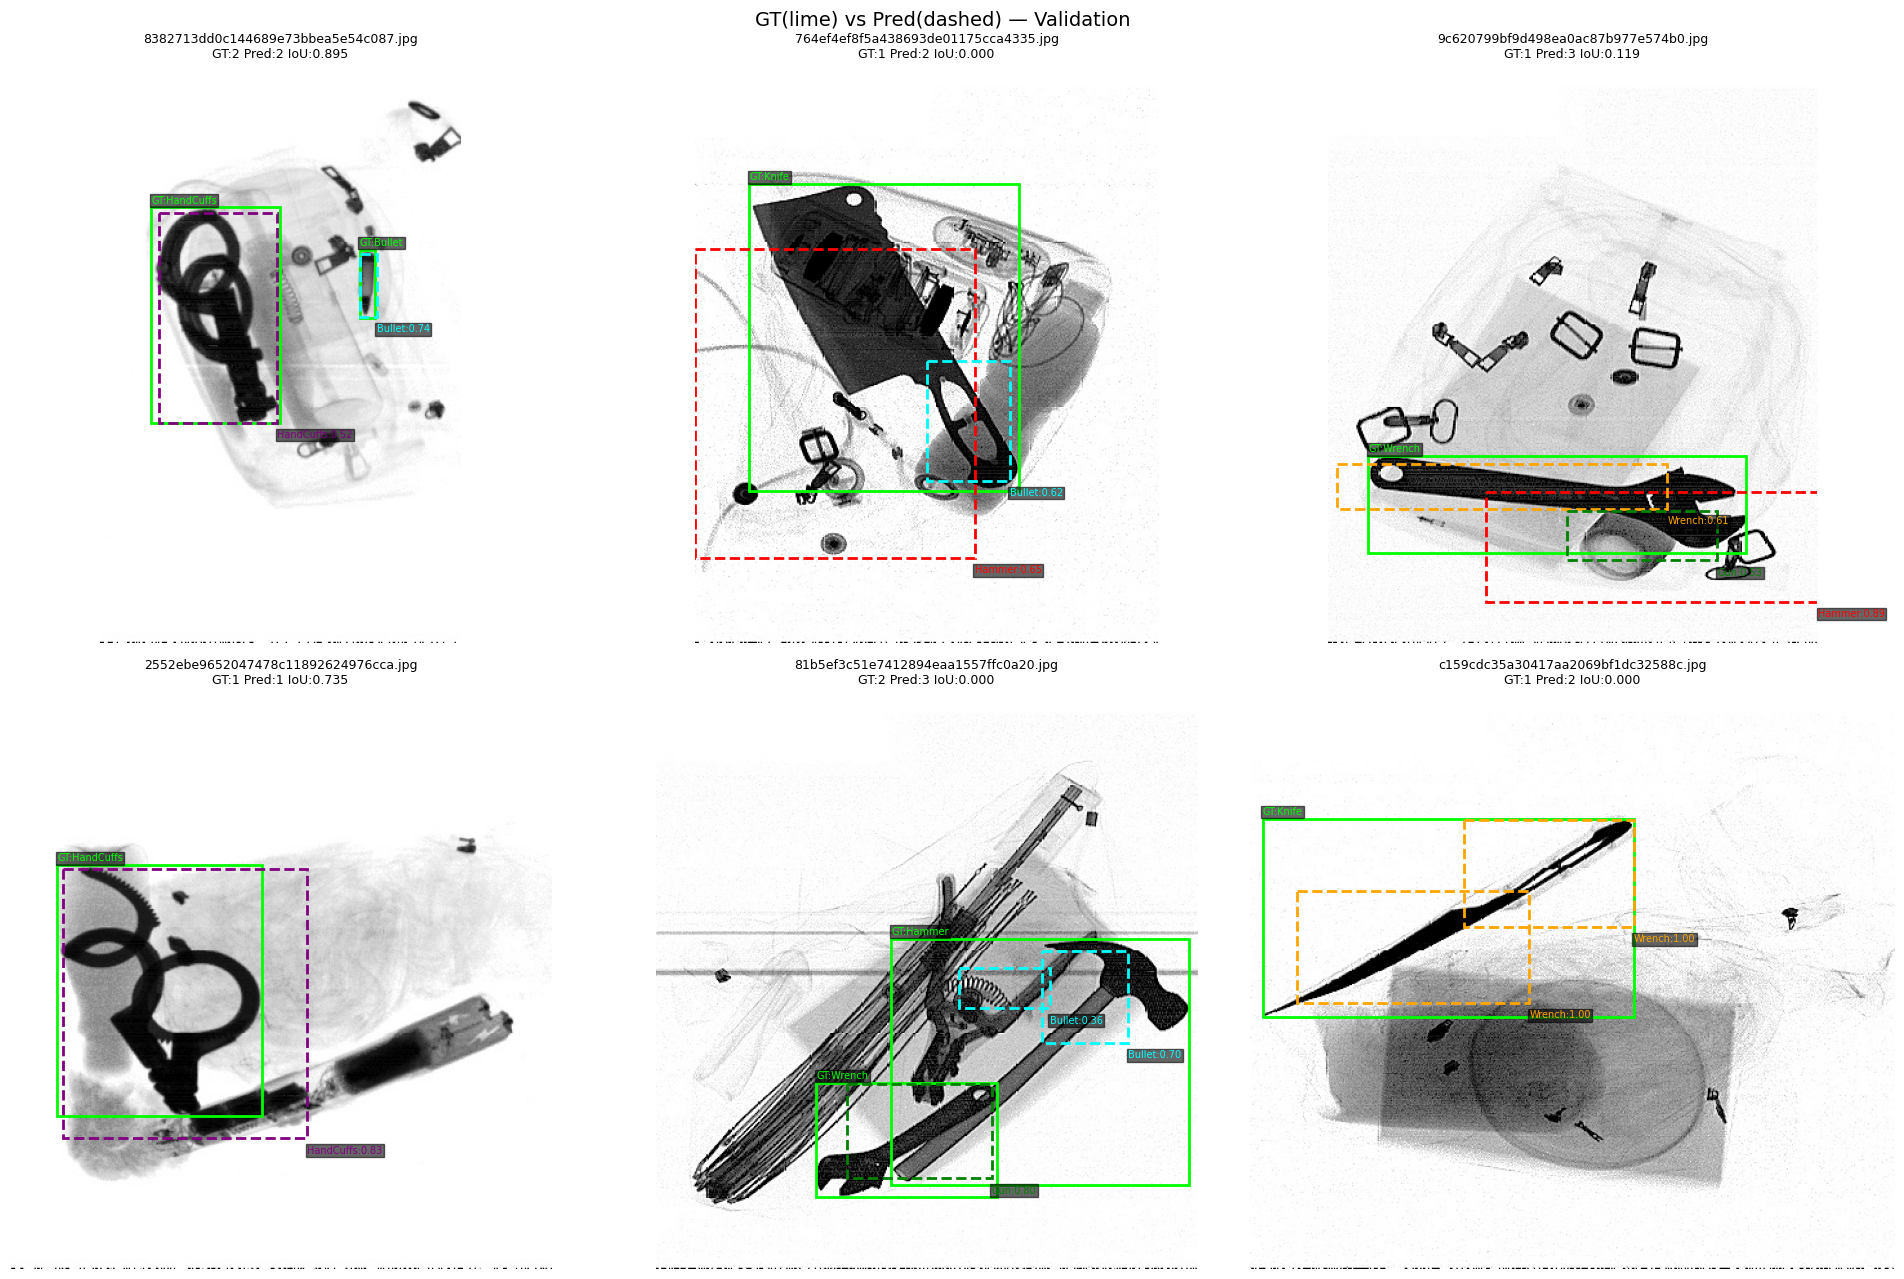

In [9]:
# ═══════════════════════════════════════════════════════════════
# CELL 10 — VISUAL TEST ON VALIDATION
# ═══════════════════════════════════════════════════════════════
val_imgs = sorted(VAL_IMG.glob('*'))
sample = random.sample(val_imgs, 6)

fig, axes = plt.subplots(2, 3, figsize=(20, 13))
for ax, img_path in zip(axes.flat, sample):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    h, w = img.shape[:2]
    gt = parse_yolo_labels(VAL_LBL / (img_path.stem + '.txt'))
    preds = detect(img, confidence_threshold=0.3)

    ax.imshow(img, cmap='gray')
    for cls,cx,cy,bw,bh in gt:
        x1,y1,x2,y2 = yolo_to_pixel(cx,cy,bw,bh,w,h)
        ax.add_patch(mpatches.Rectangle((x1,y1),x2-x1,y2-y1,lw=2,
                     edgecolor='lime',facecolor='none'))
        ax.text(x1,y1-3,f'GT:{CLASS_NAMES[cls]}',color='lime',fontsize=7,
                bbox=dict(facecolor='black',alpha=0.6,pad=1))
    for cls,cx,cy,bw,bh,sc in preds:
        x1,y1,x2,y2 = yolo_to_pixel(cx,cy,bw,bh,w,h)
        ax.add_patch(mpatches.Rectangle((x1,y1),x2-x1,y2-y1,lw=2,
                     edgecolor=CLASS_COLORS[cls],facecolor='none',ls='--'))
        ax.text(x2,y2+12,f'{CLASS_NAMES[cls]}:{sc:.2f}',color=CLASS_COLORS[cls],
                fontsize=7,bbox=dict(facecolor='black',alpha=0.6,pad=1))
    preds_e = [(c,cx,cy,bw,bh) for c,cx,cy,bw,bh,_ in preds]
    score = evaluate_frame(gt, preds_e)
    ax.set_title(f'{img_path.name}\nGT:{len(gt)} Pred:{len(preds)} IoU:{score:.3f}',fontsize=9)
    ax.axis('off')
plt.suptitle('GT(lime) vs Pred(dashed) — Validation',fontsize=14)
plt.tight_layout(); plt.show()

In [10]:
# ═══════════════════════════════════════════════════════════════
# CELL 11 — DIAGNOSTIC: proposal recall + classification
# ═══════════════════════════════════════════════════════════════
val_img_list = sorted(VAL_IMG.glob('*'))
DIAG_N = 200

prop_hits, prop_misses, cls_correct, cls_wrong, total_gt = 0,0,0,0,0
pcls_hits, pcls_misses = defaultdict(int), defaultdict(int)

for p in tqdm(val_img_list[:DIAG_N], desc='Diagnostic'):
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    h, w = img.shape[:2]
    gt = parse_yolo_labels(VAL_LBL/(p.stem+'.txt'))
    proposals = get_region_proposals(img)

    for gt_cls,cx,cy,bw,bh in gt:
        total_gt += 1
        gt_yolo = (cx,cy,bw,bh)
        best_iou, best_prop = 0, None
        for (px1,py1,px2,py2) in proposals:
            iou = compute_iou(gt_yolo, pixel_to_yolo(px1,py1,px2,py2,w,h))
            if iou > best_iou: best_iou, best_prop = iou, (px1,py1,px2,py2)

        if best_iou > 0.2:
            prop_hits += 1; pcls_hits[gt_cls] += 1
            crop = img[best_prop[1]:best_prop[3], best_prop[0]:best_prop[2]]
            feat = extract_features(crop)
            if feat is not None:
                feat_s = scaler.transform(feat.reshape(1,-1))
                feat_s = np.nan_to_num(feat_s, nan=0, posinf=0, neginf=0)
                pred = clf.predict(feat_s)[0]
                if pred == gt_cls: cls_correct += 1
                else: cls_wrong += 1
        else:
            prop_misses += 1; pcls_misses[gt_cls] += 1

print(f"\n{'='*60}")
print(f"DIAGNOSTIC — {DIAG_N} imgs, {total_gt} GT objects")
print(f"{'='*60}")
print(f"Proposal recall (IoU>0.2): {prop_hits}/{total_gt} = {prop_hits/(total_gt+1e-6)*100:.1f}%")
print(f"Classification: {cls_correct}/{prop_hits} = {cls_correct/(prop_hits+1e-6)*100:.1f}% correct")
print(f"\nPer-class proposal recall:")
for c in range(NUM_CLASSES):
    h_=pcls_hits.get(c,0); m_=pcls_misses.get(c,0)
    print(f"  {CLASS_NAMES[c]:>10}: {h_}/{h_+m_} = {h_/(h_+m_+1e-6)*100:.1f}%")

Diagnostic: 100%|██████████| 200/200 [00:20<00:00,  9.63it/s]


DIAGNOSTIC — 200 imgs, 295 GT objects
Proposal recall (IoU>0.2): 294/295 = 99.7%
Classification: 134/294 = 45.6% correct

Per-class proposal recall:
      Hammer: 33/33 = 100.0%
       Knife: 62/62 = 100.0%
         Gun: 45/45 = 100.0%
      Wrench: 56/57 = 98.2%
   HandCuffs: 51/51 = 100.0%
      Bullet: 47/47 = 100.0%


In [11]:
# ═══════════════════════════════════════════════════════════════
# CELL 12 — THRESHOLD SWEEP
# ═══════════════════════════════════════════════════════════════
SWEEP_N = 100
sweep_sub = val_img_list[:SWEEP_N]
thresholds = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]

print(f'Sweeping on {SWEEP_N} images...\n')
print(f'{"Thr":>6} {"IoU":>8} {"Dets":>6} {"Zero%":>6}')
print('-'*32)

best_s, best_t = 0, 0.2
for thr in thresholds:
    sc, dt = [], []
    for p in sweep_sub:
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        gt = parse_yolo_labels(VAL_LBL/(p.stem+'.txt'))
        raw = detect(img, confidence_threshold=thr)
        preds = [(c,cx,cy,bw,bh) for c,cx,cy,bw,bh,_ in raw]
        sc.append(evaluate_frame(gt, preds))
        dt.append(len(preds))
    m = np.mean(sc)
    z = sum(1 for s in sc if s==0)/len(sc)*100
    mk = ' ◀' if m > best_s else ''
    if m > best_s: best_s, best_t = m, thr
    print(f'{thr:>6.2f} {m:>8.4f} {np.mean(dt):>6.1f} {z:>5.0f}%{mk}')

print(f'\nBest: threshold={best_t}, IoU={best_s:.4f}')

Sweeping on 100 images...

   Thr      IoU   Dets  Zero%
--------------------------------
  0.05   0.2967    1.9    27% ◀
  0.10   0.2967    1.9    27%
  0.15   0.2967    1.9    27%
  0.20   0.2967    1.9    27%
  0.25   0.2967    1.9    27%
  0.30   0.2974    1.9    27% ◀
  0.40   0.3146    1.7    30% ◀
  0.50   0.3508    1.4    30% ◀

Best: threshold=0.5, IoU=0.3508


Full eval on 900 images (thr=0.5)...



100%|██████████| 900/900 [46:06<00:00,  3.07s/it]



MEAN IoU: 0.2750
Avg preds/img: 1.4
Median: 0.1929, Max: 0.9863
Zero frames: 346/900
>0.1 IoU: 519/900


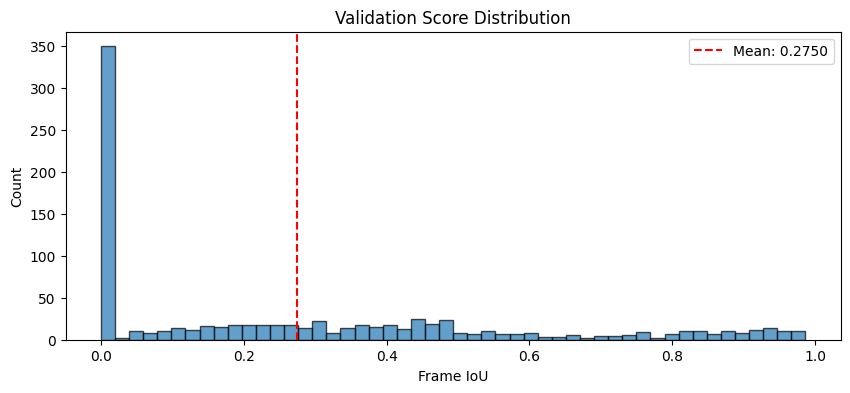

In [12]:
# ═══════════════════════════════════════════════════════════════
# CELL 13 — FULL VALIDATION (all 900)
# ═══════════════════════════════════════════════════════════════
BEST_THR = best_t
print(f'Full eval on {len(val_img_list)} images (thr={BEST_THR})...\n')

frame_scores, pred_counts = [], []
for p in tqdm(val_img_list):
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    gt = parse_yolo_labels(VAL_LBL/(p.stem+'.txt'))
    raw = detect(img, confidence_threshold=BEST_THR)
    preds = [(c,cx,cy,bw,bh) for c,cx,cy,bw,bh,_ in raw]
    frame_scores.append(evaluate_frame(gt, preds))
    pred_counts.append(len(preds))

ms = np.mean(frame_scores)
print(f'\n{"="*50}')
print(f'MEAN IoU: {ms:.4f}')
print(f'{"="*50}')
print(f'Avg preds/img: {np.mean(pred_counts):.1f}')
print(f'Median: {np.median(frame_scores):.4f}, Max: {np.max(frame_scores):.4f}')
print(f'Zero frames: {sum(1 for s in frame_scores if s==0)}/{len(frame_scores)}')
print(f'>0.1 IoU: {sum(1 for s in frame_scores if s>0.1)}/{len(frame_scores)}')

plt.figure(figsize=(10,4))
plt.hist(frame_scores, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(ms, color='red', ls='--', label=f'Mean: {ms:.4f}')
plt.xlabel('Frame IoU'); plt.ylabel('Count')
plt.title('Validation Score Distribution'); plt.legend()
plt.savefig('/content/val_dist.png', dpi=100, bbox_inches='tight')
plt.show()

WORST:


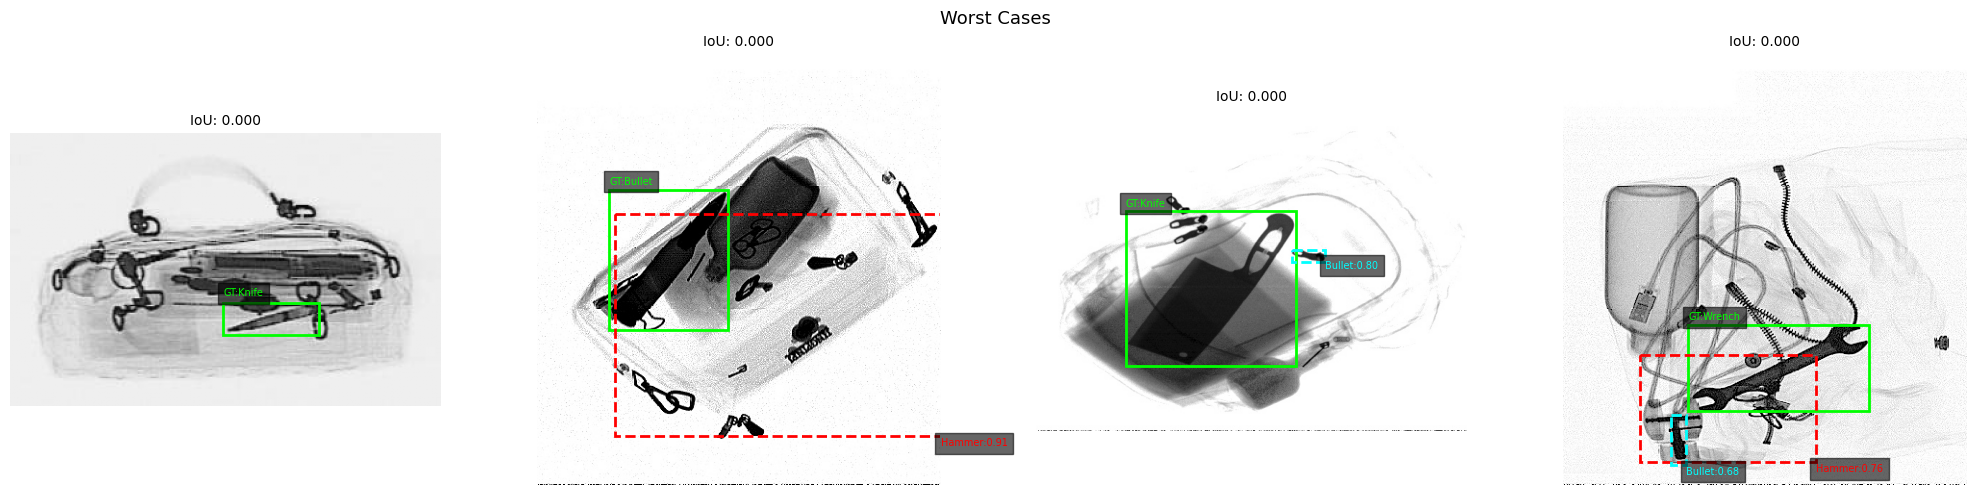

BEST:


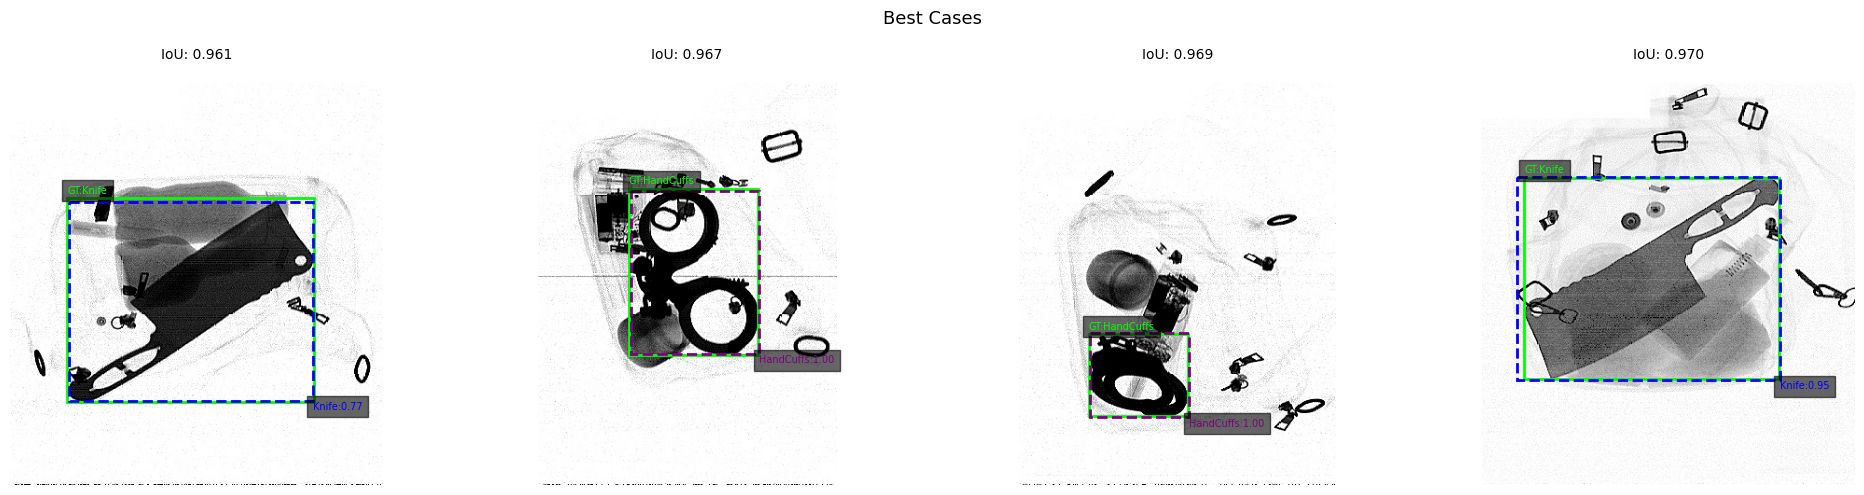

In [13]:
# ═══════════════════════════════════════════════════════════════
# CELL 14 — BEST & WORST CASES
# ═══════════════════════════════════════════════════════════════
val_results = []
for i, p in enumerate(val_img_list[:200]):
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is None: continue
    gt = parse_yolo_labels(VAL_LBL/(p.stem+'.txt'))
    raw = detect(img, confidence_threshold=BEST_THR)
    preds_e = [(c,cx,cy,bw,bh) for c,cx,cy,bw,bh,_ in raw]
    val_results.append((evaluate_frame(gt,preds_e), p, gt, raw))
val_results.sort(key=lambda x: x[0])

def show_results(results, title):
    fig, axes = plt.subplots(1, min(4,len(results)), figsize=(20,5))
    if not hasattr(axes,'__iter__'): axes=[axes]
    for ax,(sc,p,gt,preds) in zip(axes, results):
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        h,w = img.shape[:2]
        ax.imshow(img, cmap='gray')
        for cls,cx,cy,bw,bh in gt:
            x1,y1,x2,y2 = yolo_to_pixel(cx,cy,bw,bh,w,h)
            ax.add_patch(mpatches.Rectangle((x1,y1),x2-x1,y2-y1,lw=2,edgecolor='lime',facecolor='none'))
            ax.text(x1,y1-5,f'GT:{CLASS_NAMES[cls]}',color='lime',fontsize=7,
                    bbox=dict(facecolor='black',alpha=0.6))
        for cls,cx,cy,bw,bh,s in preds:
            x1,y1,x2,y2 = yolo_to_pixel(cx,cy,bw,bh,w,h)
            ax.add_patch(mpatches.Rectangle((x1,y1),x2-x1,y2-y1,lw=2,
                         edgecolor=CLASS_COLORS[cls],facecolor='none',ls='--'))
            ax.text(x2,y2+10,f'{CLASS_NAMES[cls]}:{s:.2f}',color=CLASS_COLORS[cls],fontsize=7,
                    bbox=dict(facecolor='black',alpha=0.6))
        ax.set_title(f'IoU: {sc:.3f}',fontsize=10); ax.axis('off')
    plt.suptitle(title,fontsize=13); plt.tight_layout(); plt.show()

print('WORST:'); show_results(val_results[:4], 'Worst Cases')
print('BEST:'); show_results(val_results[-4:], 'Best Cases')

In [14]:
# ═══════════════════════════════════════════════════════════════
# CELL 15 — GENERATE SUBMISSION
# ═══════════════════════════════════════════════════════════════
FINAL_THR = best_t
test_list = sorted(TEST_IMG.glob('*'))
print(f'Generating predictions for {len(test_list)} test images (thr={FINAL_THR})...\n')

rows, det_counts = [], []
for p in tqdm(test_list):
    img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
    if img is None:
        rows.append({'frame_id': p.stem, 'bbs': '[]'}); continue
    raw = detect(img, confidence_threshold=FINAL_THR)
    bbs = [[int(c), round(cx,6), round(cy,6), round(bw,6), round(bh,6)]
           for c,cx,cy,bw,bh,_ in raw]
    rows.append({'frame_id': p.stem, 'bbs': str(bbs)})
    det_counts.append(len(bbs))

df = pd.DataFrame(rows)
df.to_csv('/content/submission.csv', index=False)
print(f'Saved! Total dets: {sum(det_counts)}, avg: {np.mean(det_counts):.1f}/img')
print(f'Zero-det images: {sum(1 for d in det_counts if d==0)}')

Generating predictions for 900 test images (thr=0.5)...



100%|██████████| 900/900 [41:49<00:00,  2.79s/it]

Saved! Total dets: 1274, avg: 1.4/img
Zero-det images: 153


In [15]:
# ═══════════════════════════════════════════════════════════════
# CELL 16 — SANITY CHECK
# ═══════════════════════════════════════════════════════════════
df_c = pd.read_csv('/content/submission.csv')
errors, total_boxes = 0, 0
cc = defaultdict(int)
for _,row in df_c.iterrows():
    try:
        bbs = ast.literal_eval(row['bbs'])
        for bb in bbs:
            assert len(bb)==5 and 0<=bb[0]<=5
            cc[int(bb[0])] += 1; total_boxes += 1
    except: errors += 1

expected = {0:187, 1:224, 2:270, 3:228, 4:200, 5:212}
print(f'Errors: {errors}, Total boxes: {total_boxes}\n')
for cls in range(NUM_CLASSES):
    print(f'  {CLASS_NAMES[cls]:>10}: {cc.get(cls,0):>4} predicted (expect ~{expected[cls]})')
if errors == 0:
    print('\n✅ Valid!')
    from google.colab import files
    files.download('/content/submission.csv')

Errors: 0, Total boxes: 1274

      Hammer:  236 predicted (expect ~187)
       Knife:  171 predicted (expect ~224)
         Gun:  268 predicted (expect ~270)
      Wrench:  173 predicted (expect ~228)
   HandCuffs:  185 predicted (expect ~200)
      Bullet:  241 predicted (expect ~212)

✅ Valid!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
# ═══════════════════════════════════════════════════════════════
# CELL 17 — SAVE EVERYTHING TO DRIVE
# ═══════════════════════════════════════════════════════════════
import os, shutil, pickle

SAVE_DIR = '/content/drive/MyDrive/xray_v6'
os.makedirs(SAVE_DIR, exist_ok=True)

with open(f'{SAVE_DIR}/pipeline.pkl', 'wb') as f:
    pickle.dump({'clf': clf, 'scaler': scaler,
                 'class_size': class_size}, f)

shutil.copy('/content/submission.csv', f'{SAVE_DIR}/submission.csv')
if os.path.exists('/content/val_dist.png'):
    shutil.copy('/content/val_dist.png', f'{SAVE_DIR}/val_dist.png')

with open(f'{SAVE_DIR}/results.txt', 'w') as f:
    f.write(f'V6 Results — XGBoost + Multi-method proposals\n')
    f.write(f'Best threshold: {best_t}\n')
    f.write(f'Val mean IoU: {ms:.4f}\n')
    f.write(f'Proposal recall: {prop_hits}/{total_gt} = {prop_hits/(total_gt+1e-6)*100:.1f}%\n')
    f.write(f'Classification acc: {cls_correct}/{prop_hits} = {cls_correct/(prop_hits+1e-6)*100:.1f}%\n')
    f.write(f'Total test dets: {sum(det_counts)}\n')
    for cls in range(NUM_CLASSES):
        f.write(f'  {CLASS_NAMES[cls]}: {cc.get(cls,0)} (expect ~{expected[cls]})\n')

print(f'Saved to {SAVE_DIR}')
print(f'\n{"="*50}')
print(f'DONE! submission.csv ready.')
print(f'{"="*50}')

Saved to /content/drive/MyDrive/xray_v6

DONE! submission.csv ready.
